Title:  Netflix Top 10 Data Story: Global Viewing Insights and Strategic Recommendations <br>
Class: DSC640-T301 Data presentation and visualization (2263) <br>
Student: Roshan GC <br>
Professor: Benjamin Schneider <br>
Date: 12/11/2025

## 1. Import Libraries

In [42]:
#importing the required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.style.use("ggplot")

## 2. Load Dataset

In [43]:
# loading the dataset from local directory
global_df   = pd.read_excel("/users/roshan/DSC640/all-weeks-global-netflix.xlsx")
countries_df = pd.read_excel("/users/roshan/DSC640/all-weeks-countries-netflix.xlsx")
popular_df  = pd.read_excel("/users/roshan/DSC640/most-popular-netflix.xlsx")

print("\nAll-weeks-global-netflix data:\n", global_df.head())
print("\nAll-weeks-countries-netflix data:\n", countries_df.head())
print("\nMost popular netflix data:\n", popular_df.head())


All-weeks-global-netflix data:
          week         category  weekly_rank                     show_title  \
0  2024-04-14  Films (English)            1              What Jennifer Did   
1  2024-04-14  Films (English)            2  Woody Woodpecker Goes to Camp   
2  2024-04-14  Films (English)            3                          Scoop   
3  2024-04-14  Films (English)            4                          Glass   
4  2024-04-14  Films (English)            5                   Megan Leavey   

  season_title  weekly_hours_viewed  runtime  weekly_views  \
0          NaN             26100000   1.4500    18000000.0   
1          NaN             19600000   1.6667    11800000.0   
2          NaN             14600000   1.7167     8500000.0   
3          NaN             11000000   2.1500     5100000.0   
4          NaN              9700000   1.9333     5000000.0   

   cumulative_weeks_in_top_10  is_staggered_launch episode_launch_details  
0                           1                Fals

## 3. Data Cleaning

In [44]:
# Ensuring dates are datetime
global_df["week"] = pd.to_datetime(global_df["week"])
countries_df["week"] = pd.to_datetime(countries_df["week"])

# Strip whitespace from titles
for df in [global_df, countries_df, popular_df]:
    df["show_title"] = df["show_title"].str.strip()

## 4. Visualization

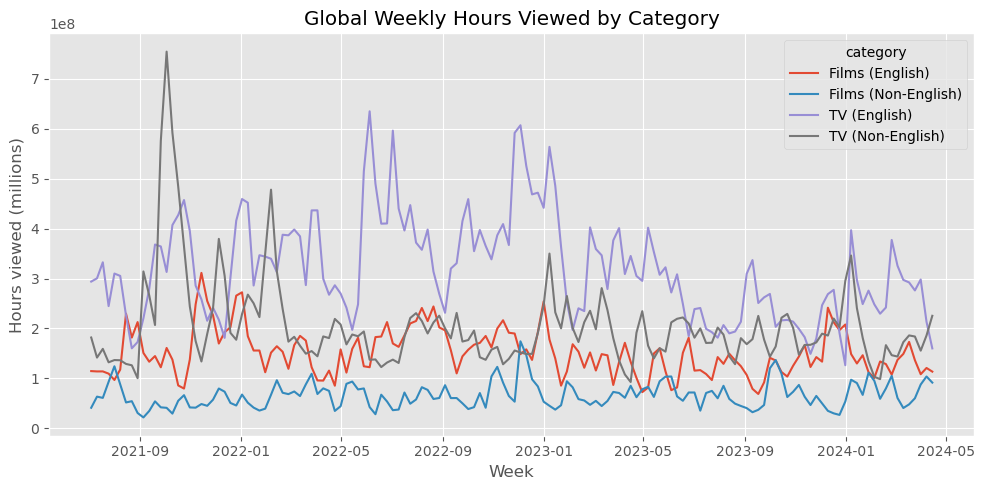

In [45]:
# 1 – Global viewing by category (TV vs Film)
cat_trend = (
    global_df
    .groupby(["week", "category"], as_index=False)["weekly_hours_viewed"]
    .sum()
)

plt.figure(figsize=(10,5))
sns.lineplot(data=cat_trend, x="week", y="weekly_hours_viewed", hue="category")
plt.title("Global Weekly Hours Viewed by Category")
plt.xlabel("Week")
plt.ylabel("Hours viewed (millions)")
plt.tight_layout()
plt.show()


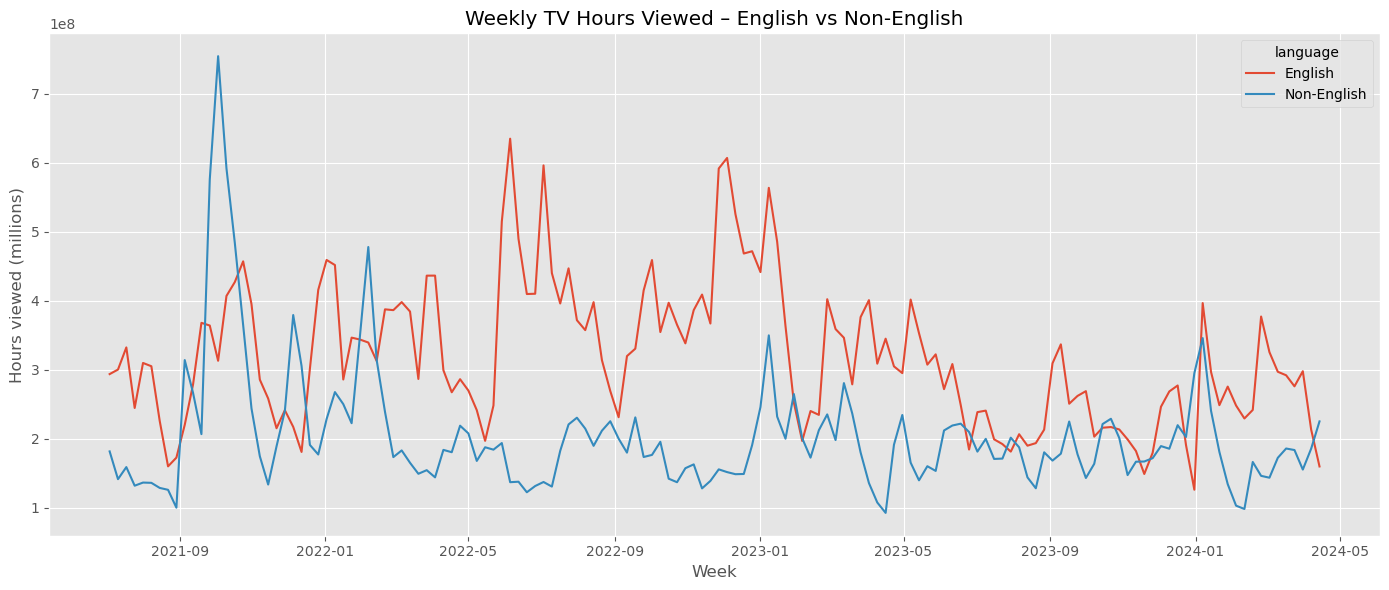

In [ ]:
# 2 - TV only (both English and Non-English)

tv_global = global_df[global_df["category"].str.contains("TV")].copy()

tv_global["language"] = np.where(
    tv_global["category"].str.contains("Non-English"),
    "Non-English",
    "English"
)

lang_trend = (
    tv_global
    .groupby(["week", "language"], as_index=False)["weekly_hours_viewed"]
    .sum()
)

plt.figure(figsize=(14,6))
sns.lineplot(
    data=lang_trend,
    x="week",
    y="weekly_hours_viewed",
    hue="language"
)
plt.title("Weekly TV Hours Viewed – English vs Non-English")
plt.xlabel("Week")
plt.ylabel("Hours viewed (millions)")
plt.tight_layout()
plt.show()

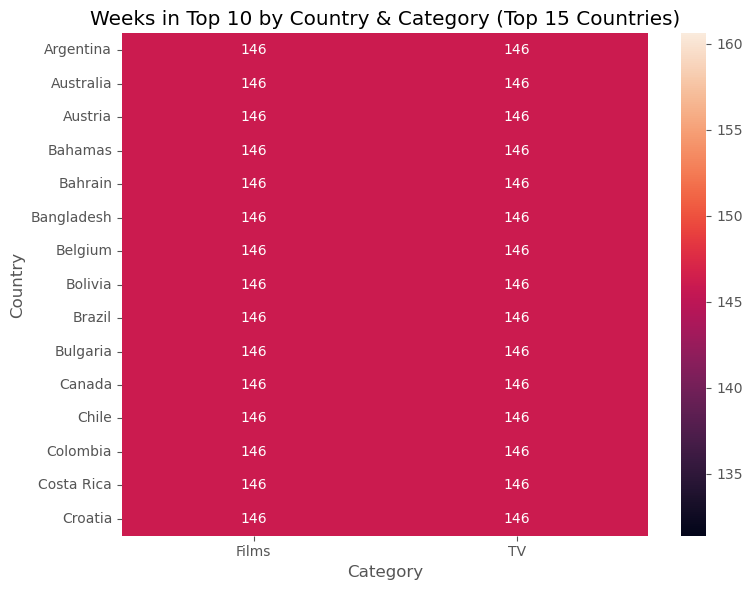

In [47]:
# 3 – Heatmap of weeks in Top 10 by countries & category

weeks_by_country_cat = (
    countries_df
    .groupby(["country_name", "category"])["week"]  
    .nunique()
    .reset_index(name="weeks_in_top10")
)

top_countries = (
    weeks_by_country_cat
    .groupby("country_name")["weeks_in_top10"]
    .sum()
    .nlargest(15)
    .index
)

heat = weeks_by_country_cat[weeks_by_country_cat["country_name"].isin(top_countries)]
heat_pivot = heat.pivot(index="country_name", columns="category", values="weeks_in_top10")

plt.figure(figsize=(8,6))
sns.heatmap(heat_pivot, annot=True, fmt=".0f")
plt.title("Weeks in Top 10 by Country & Category (Top 15 Countries)")
plt.xlabel("Category")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


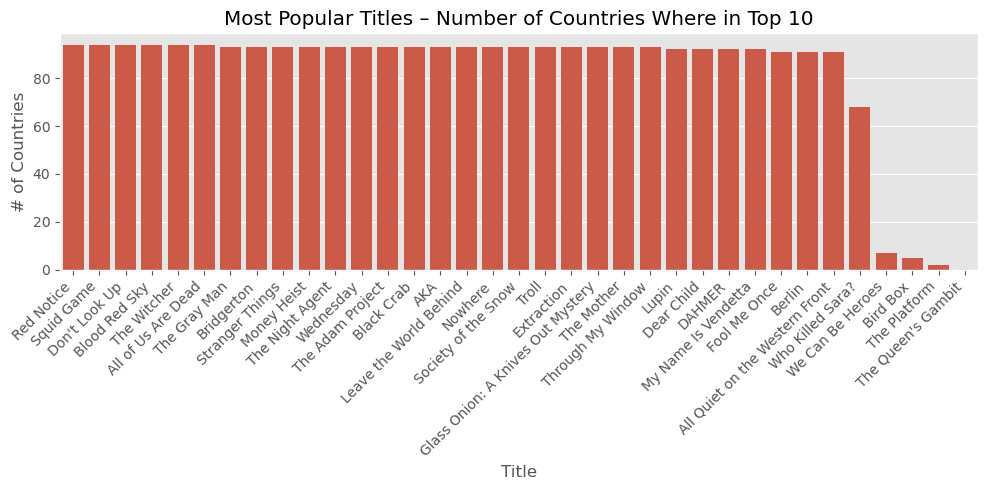

In [49]:
# 4 – For most popular titles, how many countries saw them in Top 10

country_col = "country_name"

countries_per_popular = (
    countries_df[countries_df["show_title"].isin(popular_df["show_title"])]
    .groupby("show_title")[country_col]
    .nunique()
    .reset_index(name="num_countries")
)

top_popular_countries = popular_df.merge(
    countries_per_popular, on="show_title", how="left"
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_popular_countries.sort_values("num_countries", ascending=False),
    x="show_title", y="num_countries"
)
plt.xticks(rotation=45, ha="right")
plt.title("Most Popular Titles – Number of Countries Where in Top 10")
plt.xlabel("Title")
plt.ylabel("# of Countries")
plt.tight_layout()
plt.show()


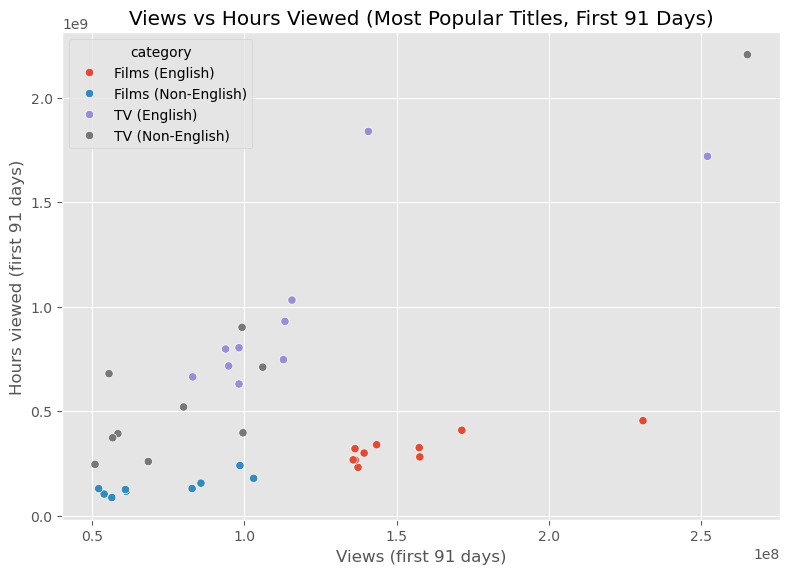

In [50]:
# 5 – Scatter plot of weeks in Top 10 vs hours viewed
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=popular_df,
    x="views_first_91_days",
    y="hours_viewed_first_91_days",
    hue="category"
)
plt.title("Views vs Hours Viewed (Most Popular Titles, First 91 Days)")
plt.xlabel("Views (first 91 days)")
plt.ylabel("Hours viewed (first 91 days)")
plt.tight_layout()
plt.show()


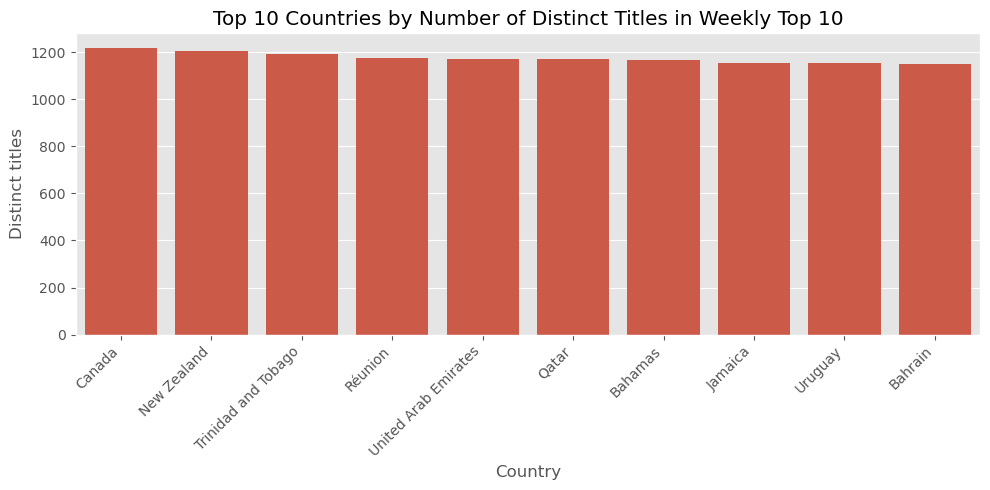

In [51]:
# 9. VISUAL 6 – Country breadth of content

distinct_titles_by_country = (
    countries_df
    .groupby("country_name")["show_title"]  
    .nunique()
    .reset_index(name="distinct_titles")
    .sort_values("distinct_titles", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(data=distinct_titles_by_country, x="country_name", y="distinct_titles")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Countries by Number of Distinct Titles in Weekly Top 10")
plt.xlabel("Country")
plt.ylabel("Distinct titles")
plt.tight_layout()
plt.show()
